# Benchmarks

## Initialize

In [8]:
#library(Rmisc)
library(dtplyr)
library(tidyverse)
library(glue)
library(arrow)
library(patchwork)
library(data.table)
library("jsonlite")
library(ggthemes)

In [9]:
if (grepl("sc", Sys.info()[["nodename"]], fixed=TRUE)) {
    base_path = "/sc-projects/sc-proj-ukb-cvd"
} else {
    base_path = "/data/analysis/ag-reils/ag-reils-shared/cardioRS"}
print(base_path)

project_label="22_medical_records"
project_path = glue("{base_path}/results/projects/{project_label}")
figure_path = glue("{project_path}/figures")
output_path = glue("{project_path}/data")

experiment = 220627
experiment_path = glue("{output_path}/{experiment}")

[1] "/sc-projects/sc-proj-ukb-cvd"


In [10]:
base_size = 8
title_size = 10
facet_size = 10
geom_text_size=3
theme_set(theme_classic(base_size = base_size) + 
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0), 
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major=element_line()))

In [11]:
colors_dict = read_json("colors.json")
color_map <- c(
    "Identity(AgeSex)+MLP" = colors_dict$pastel$red$mid,
    "Identity(Records)+MLP" = colors_dict$pastel$red$mid,
    "GNN(Records)+MLP" = colors_dict$pastel$red$mid,
    "Identity(AgeSex+Records)+MLP" = colors_dict$pastel$red$mid,
    "GNN(AgeSex+Records)+MLP" = colors_dict$pastel$red$mid
)

In [12]:
endpoint_defs = arrow::read_feather(glue("{output_path}/phecode_defs_220306.feather")) %>% arrange(endpoint)

In [13]:
endpoint_map = endpoint_defs$phecode_string
names(endpoint_map) =  endpoint_defs$endpoint
#endpoint_order_freq = (outcome_freq %>% arrange(desc(freq)))$endpoint

In [14]:
endpoint_order = (endpoint_defs %>% arrange(as.numeric(phecode)))$endpoint

In [15]:
endpoint_selection = c(
'phecode_164',
'phecode_179',
'phecode_202-2',
'phecode_284',
'phecode_401',
'phecode_404-1',
'phecode_413-21',
'phecode_413-32',
'phecode_416-21',
'phecode_420',
'phecode_424',
'phecode_431-1',
'phecode_438-6',
'phecode_440-3',
'phecode_444-13',
'phecode_448',
'phecode_468',
'phecode_474',
'phecode_542-4',
'phecode_583',
'phecode_665-1',
'phecode_705-1',
'phecode_718',
'OMOP_4306655'
    )

## Load data

# Load Benchmarks

In [16]:
name = "hrs_endpoints"
hrs_endpoints = arrow::read_feather(glue("{experiment_path}/{name}.feather"), col_select=c("endpoint", "score", "partition", "hrs_mh", "hrs_mh_age", "hrs_mh_sex")) %>% left_join(endpoint_defs) 

Joining, by = "endpoint"



In [17]:
hrs_endpoints

endpoint,score,partition,hrs_mh,hrs_mh_age,hrs_mh_sex,phecode,phecode_string,phecode_category,sex,ICD10_only,phecode_top,leaf
<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>
OMOP_4306655,ASCVD+MedicalHistory,0,2.724344,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,1,2.657619,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,2,2.635044,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,3,2.660294,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,4,2.722256,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,5,2.851670,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,6,2.764931,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,7,2.704515,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA
OMOP_4306655,ASCVD+MedicalHistory,8,2.660392,NA,NA,4306655,All-Cause Death,Death,Both,NA,NA,NA


In [18]:
hrs = hrs_endpoints %>% 
    group_by(endpoint, score, phecode_string, phecode_category) %>% 
    #filter(score %in% c("MedicalHistory", "Age+Sex+MedicalHistory", "Age+Sex+MedicalHistory+I(Age*MH)")) %>%
    #mutate(endpoint = factor(endpoint, levels=endpoints_sorted)) %>%
    #mutate(phecode_category = factor(phecode_category, levels=pcats_sorted)) %>%
    select(endpoint, score, hrs_mh, hrs_mh_age, hrs_mh_sex, phecode_string, phecode_category) %>%
    ungroup()
hrs

endpoint,score,hrs_mh,hrs_mh_age,hrs_mh_sex,phecode_string,phecode_category
<glue>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
OMOP_4306655,ASCVD+MedicalHistory,2.724344,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.657619,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.635044,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.660294,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.722256,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.851670,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.764931,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.704515,NA,NA,All-Cause Death,Death
OMOP_4306655,ASCVD+MedicalHistory,2.660392,NA,NA,All-Cause Death,Death


In [19]:
unique(hrs$score)

[1] "ASCVD+MedicalHistory"   "Age+Sex+MedicalHistory" "MedicalHistory"        
[4] "QRISK3+MedicalHistory"  "SCORE2+MedicalHistory"

In [20]:
purrr::map_dfr(integer(100), ~ hrs %>% group_by(endpoint, score) %>% sample_frac(1, replace=TRUE), .id="i") -> temp_hrs

In [21]:
library(ggdist)

Warning message:
“package ‘ggdist’ was built under R version 4.0.5”


In [22]:
temp_hrs_mh = temp_hrs %>% group_by(endpoint, score, phecode_string, phecode_category) %>% median_qi(hrs_mh, hrs_mh_age, hrs_mh_sex, na.rm=TRUE)

In [23]:
temp_hrs_linear = temp_hrs %>% ungroup() %>%
    filter(score %in% c("MedicalHistory", "Age+Sex+MedicalHistory", "SCORE2+MedicalHistory", "ASCVD+MedicalHistory","QRISK3+MedicalHistory")) %>%
    group_by(endpoint, score, phecode_string, phecode_category) %>% 
    median_qi(`hrs_mh`, na.rm=TRUE) %>% rename(hr = `hrs_mh`) %>%
    mutate(hr = round(hr, 2), .lower=round(.lower, 2), .upper=round(.upper, 2)) %>%#c(hr, .lower, .upper), round, 1) %>%
    mutate(HR_MedicalHistory = glue("{hr} ({.lower}, {.upper})")) %>% 
    select(endpoint, score, phecode_string, phecode_category, HR_MedicalHistory) %>%
    pivot_wider(names_from="score", values_from="HR_MedicalHistory") %>% 
    select(all_of(c("phecode_category", "endpoint", "phecode_string", "MedicalHistory", 'Age+Sex+MedicalHistory',  "SCORE2+MedicalHistory", "ASCVD+MedicalHistory","QRISK3+MedicalHistory"))) %>% 
    mutate(endpoint = factor(endpoint, levels = endpoint_order)) %>% 
    arrange(endpoint) %>%
    #mutate(endpoint = recode(endpoint, !!!endpoint_map)) %>%
    ungroup()
    
temp_hrs_linear

phecode_category,endpoint,phecode_string,MedicalHistory,Age+Sex+MedicalHistory,SCORE2+MedicalHistory,ASCVD+MedicalHistory,QRISK3+MedicalHistory
<chr>,<fct>,<chr>,<glue>,<glue>,<glue>,<glue>,<glue>
ID,phecode_001,Salmonella,"3.43 (2.87, 3.98)","3.39 (2.93, 4.07)","3.46 (2.97, 4.1)","3.44 (2.88, 4.01)","3.71 (3.13, 4.44)"
ID,phecode_002,Staphylococcus,"2.8 (2.66, 2.92)","2.8 (2.64, 2.89)","2.79 (2.64, 2.89)","2.86 (2.71, 3)","2.87 (2.72, 3.02)"
ID,phecode_002-1,Staphylococcus aureus,"2.78 (2.69, 2.96)","2.76 (2.68, 2.95)","2.76 (2.69, 2.95)","2.85 (2.78, 3.07)","2.87 (2.79, 3.1)"
ID,phecode_003,Escherichia coli,"2.9 (2.72, 3.11)","2.83 (2.66, 3)","2.81 (2.63, 2.96)","2.84 (2.64, 2.97)","2.81 (2.65, 2.98)"
ID,phecode_004,Streptococcus,"2.96 (2.69, 3.24)","2.94 (2.67, 3.23)","2.94 (2.67, 3.23)","2.97 (2.69, 3.29)","3.02 (2.75, 3.34)"
ID,phecode_004-1,Streptococcus pneumoniae,"3.05 (2.88, 3.45)","3.04 (2.9, 3.44)","3.02 (2.88, 3.42)","3.02 (2.88, 3.42)","3.11 (2.94, 3.47)"
ID,phecode_004-2,Group A Streptococcus,"3.27 (3, 3.72)","3.32 (3, 3.75)","3.42 (3.08, 3.85)","3.48 (3.11, 4)","3.45 (3.09, 4.04)"
ID,phecode_004-3,Group B Streptococcus,"2.95 (2.83, 3.19)","3.01 (2.83, 3.2)","2.96 (2.83, 3.2)","3.13 (2.97, 3.39)","3.14 (2.95, 3.39)"
ID,phecode_005,Mycobacteria,"3.17 (2.93, 3.4)","3.19 (2.93, 3.4)","3.2 (2.94, 3.41)","3.05 (2.82, 3.27)","3.12 (2.89, 3.38)"


In [19]:
temp_int_age = temp_hrs %>% ungroup() %>%
    filter(score %in% c("Age+Sex+MedicalHistory+I(Age*MH)")) %>%
    pivot_longer(all_of(c("hrs_mh", "hrs_mh_age", "hrs_mh_sex")), names_to="variable", values_to="hr") %>%
    filter(variable == "hrs_mh_age")

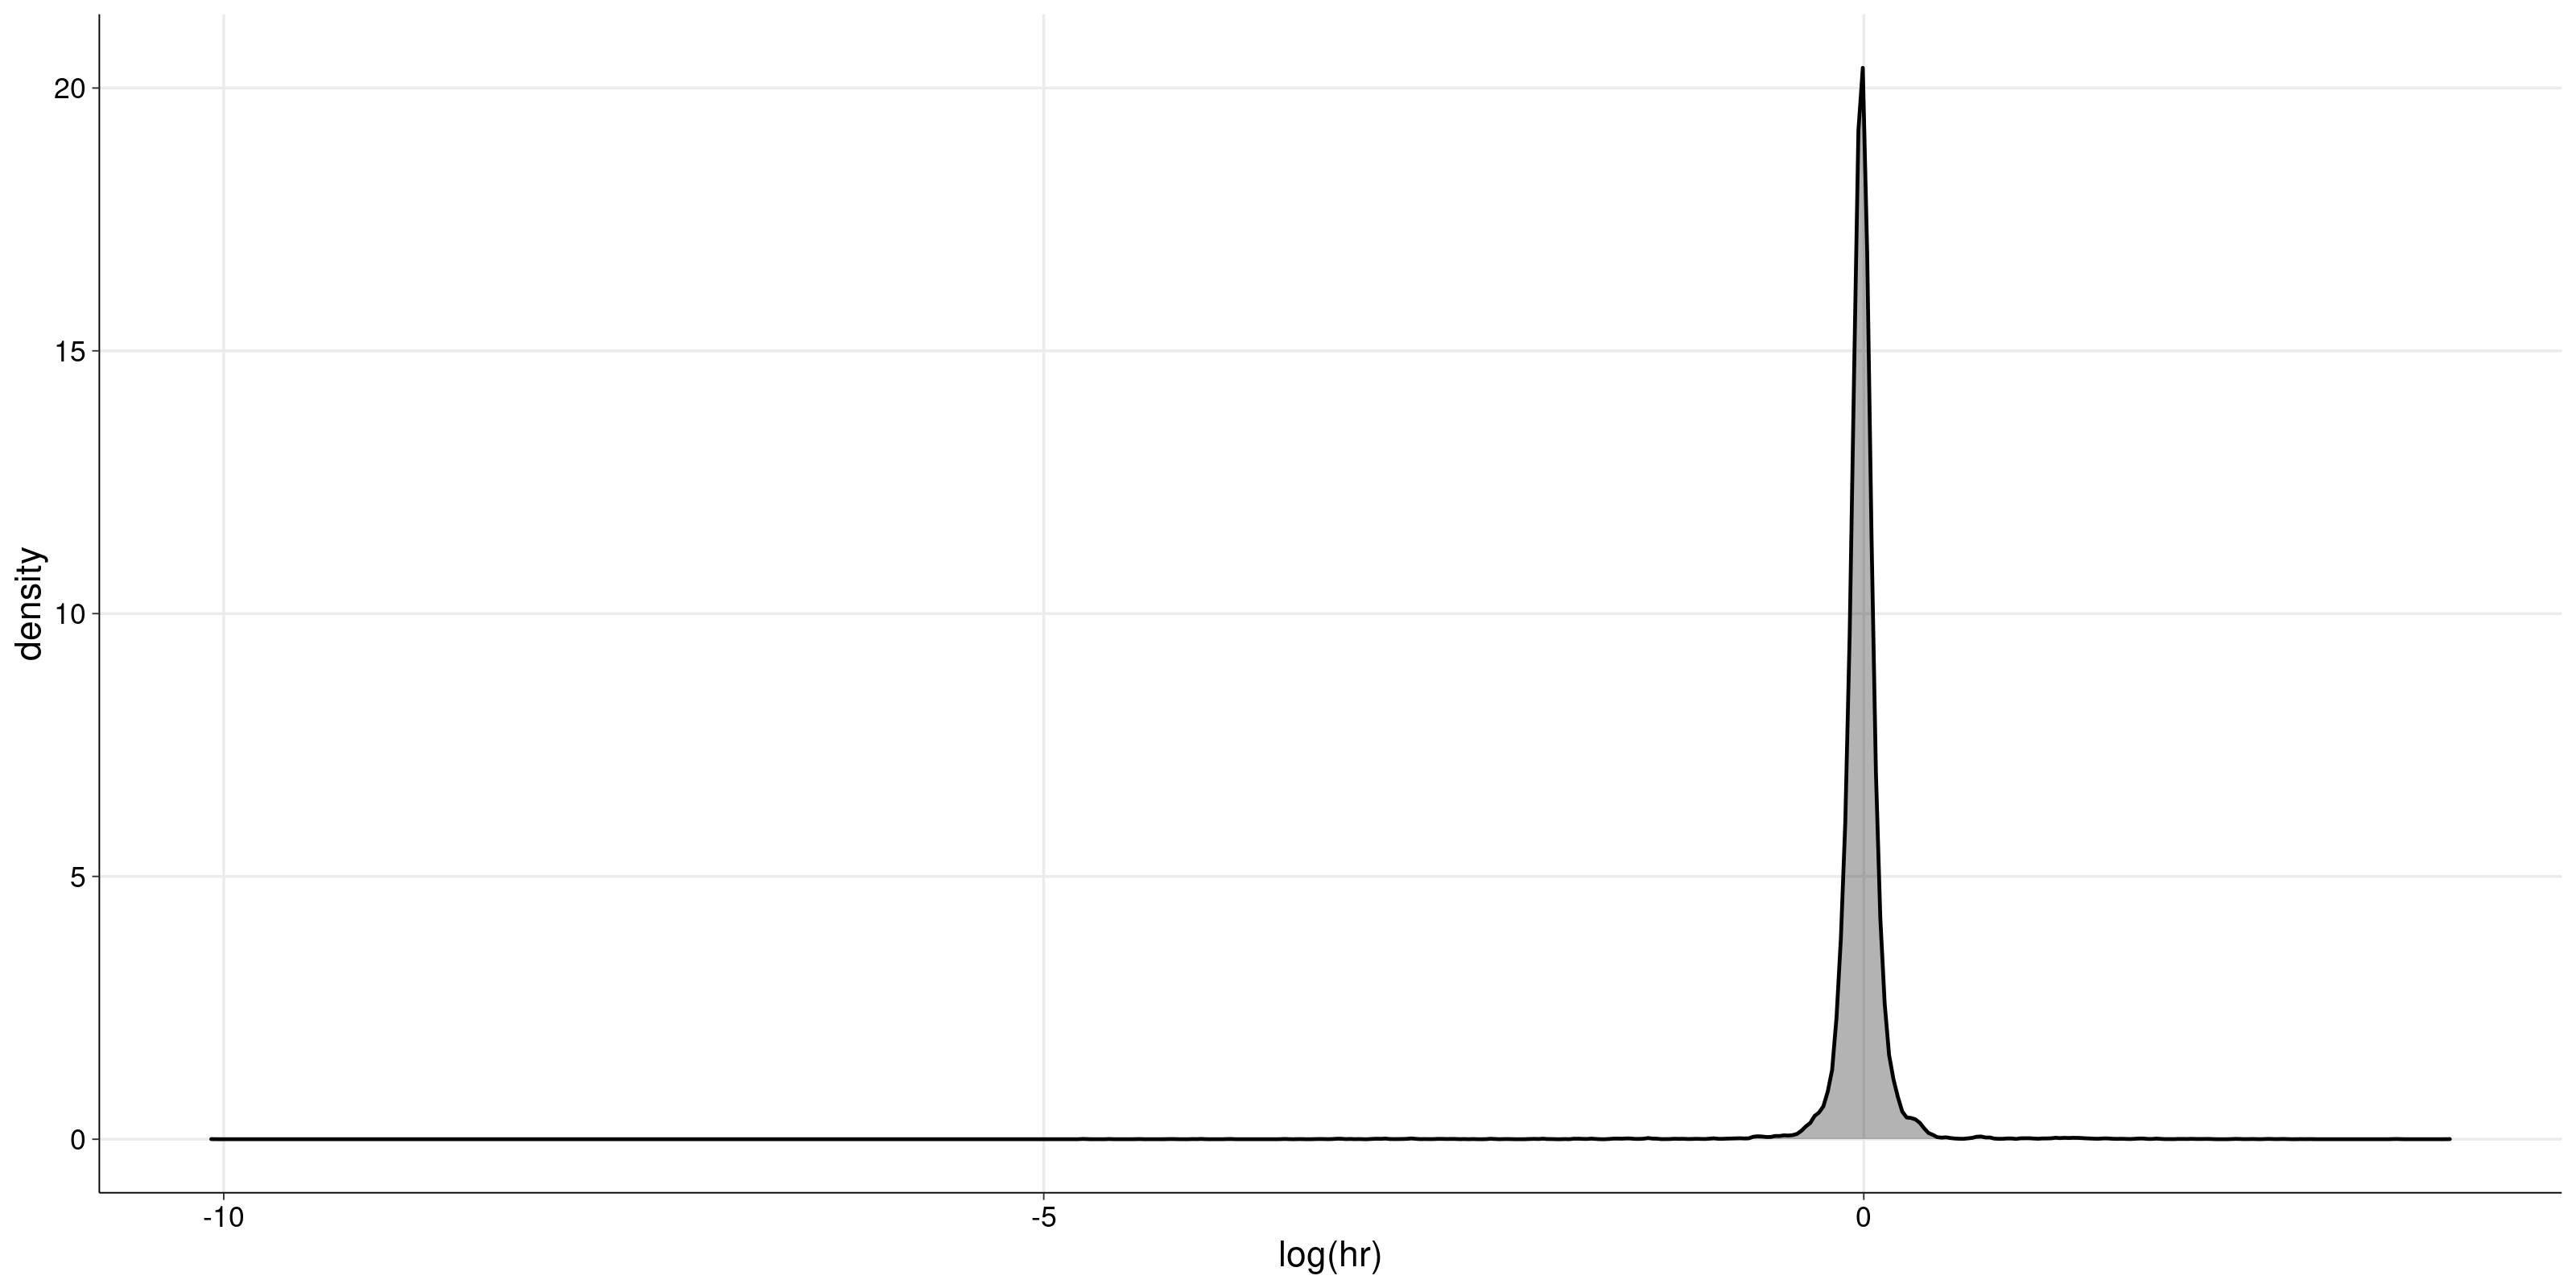

In [86]:
plot_width = 10; plot_height=5; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

ggplot(temp_int_age, aes(x=log(hr))) + geom_density(fill="black", alpha=0.3)

In [87]:
temp_int_sex= temp_hrs %>% ungroup() %>%
    filter(score %in% c("Age+Sex+MedicalHistory+I(Age*MH)")) %>%
    pivot_longer(all_of(c("hrs_mh", "hrs_mh_age", "hrs_mh_sex")), names_to="variable", values_to="hr") %>%
    filter(variable == "hrs_mh_sex")

Warning message:
“Removed 284287 rows containing non-finite values (stat_density).”


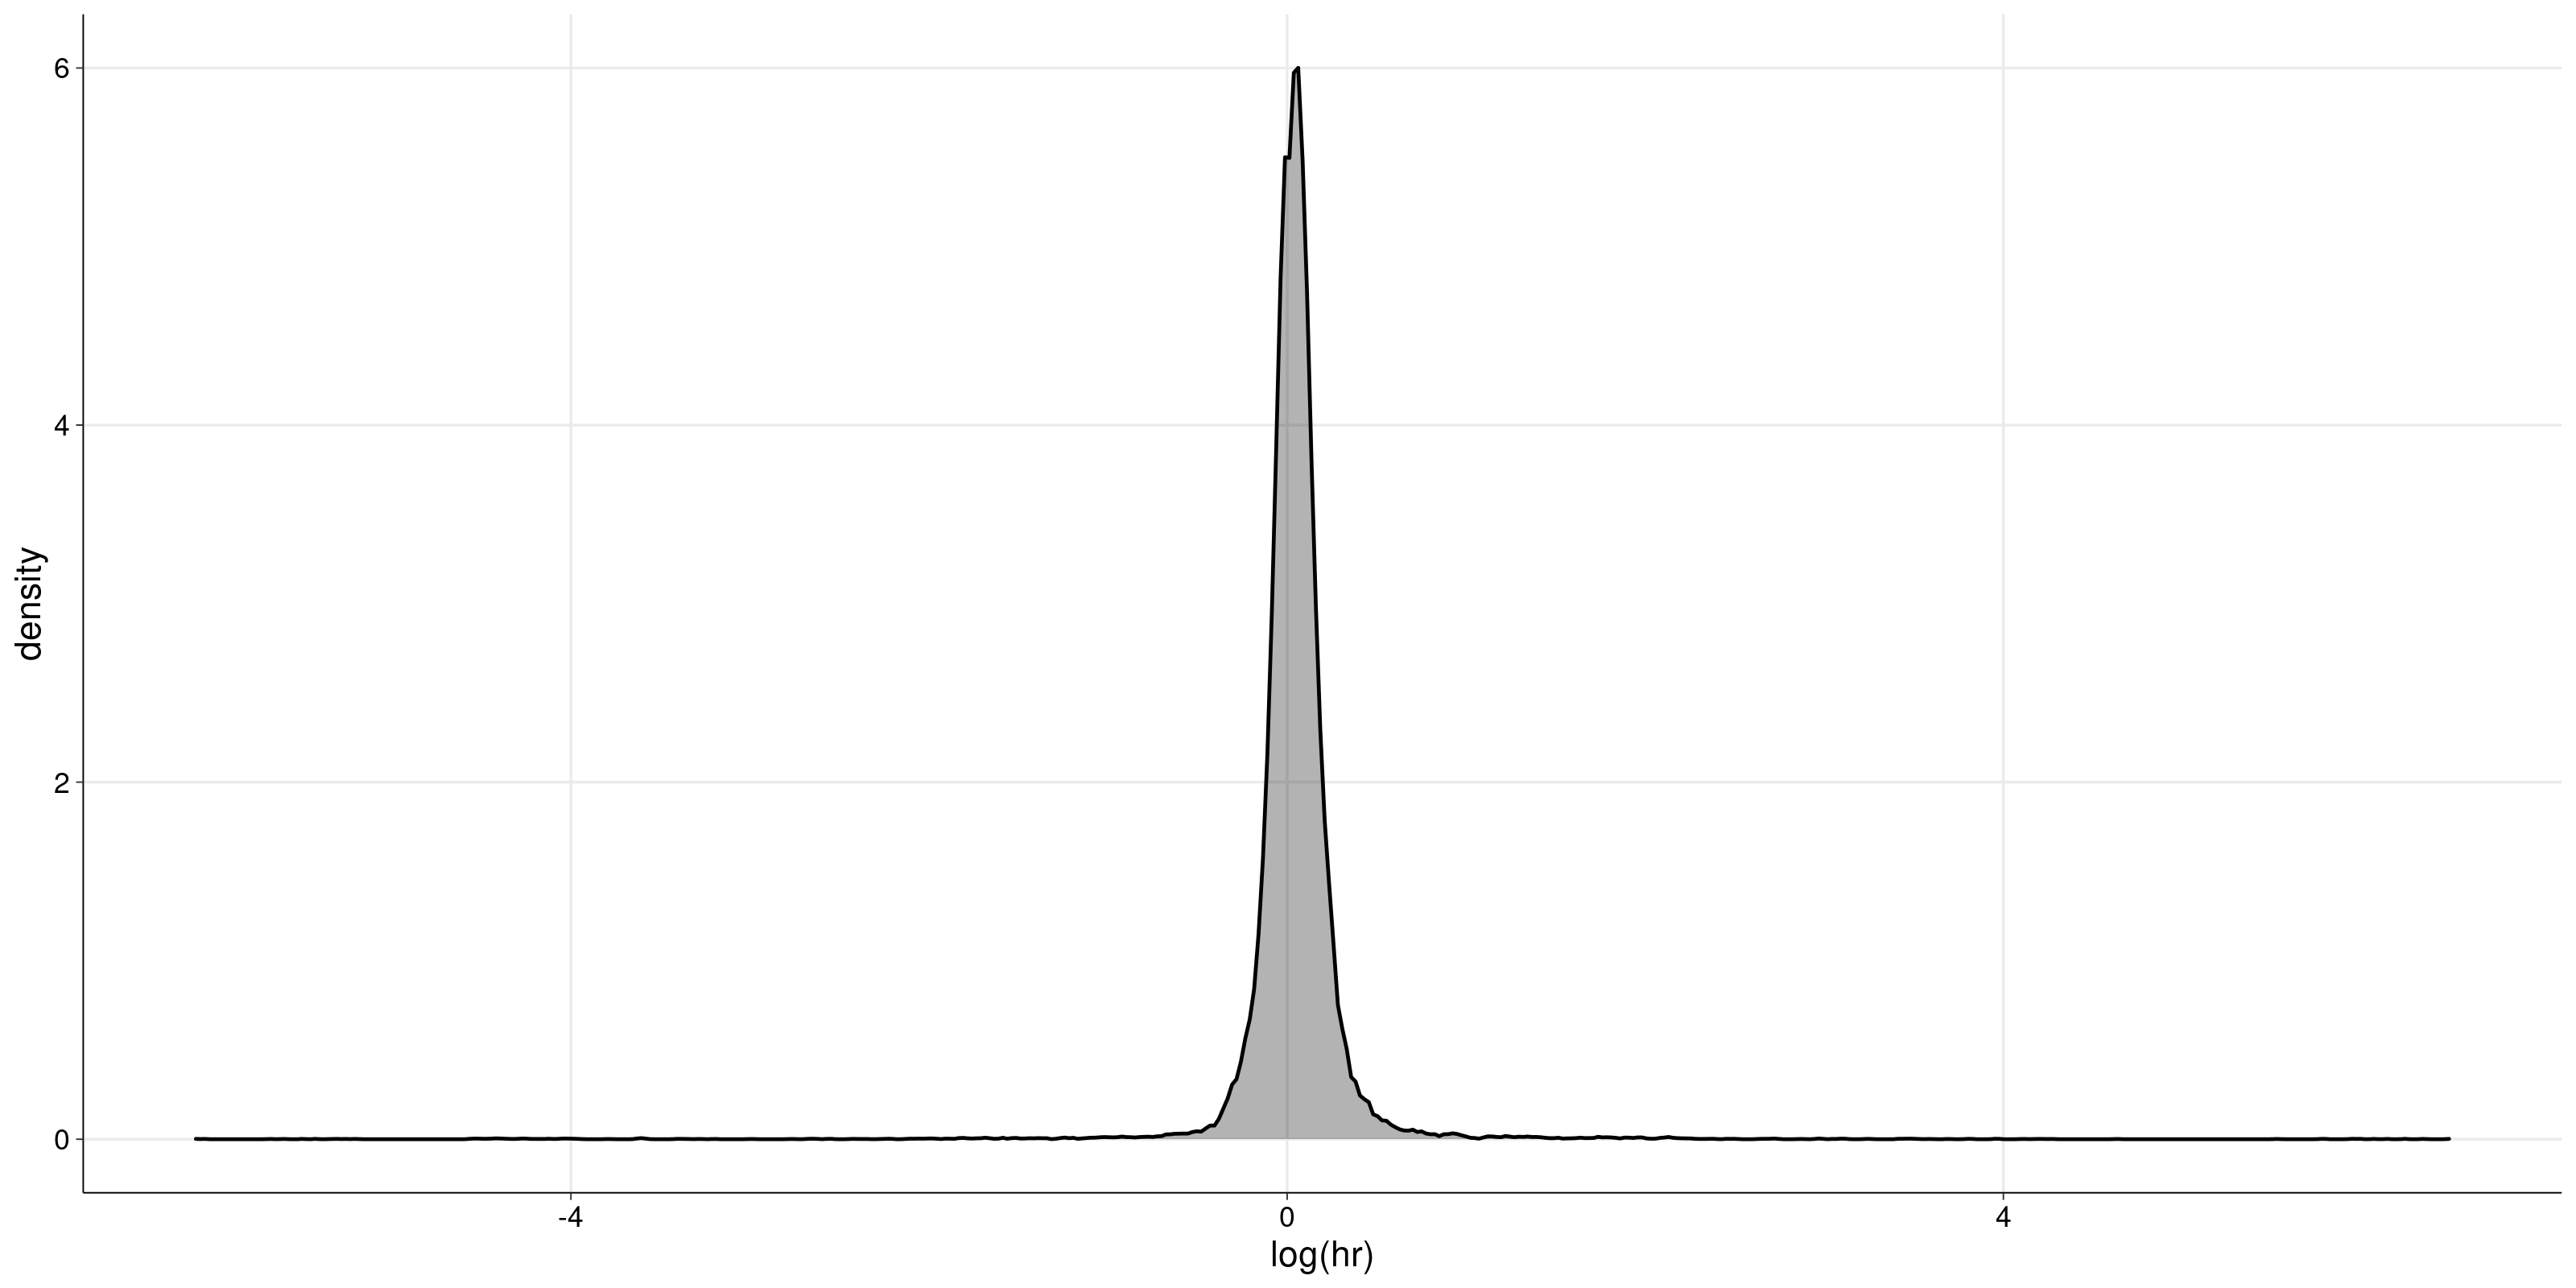

In [88]:
plot_width = 10; plot_height=5; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

ggplot(temp_int_sex, aes(x=log(hr))) + geom_density(fill="black", alpha=0.3)

In [74]:
temp_hrs_int = temp_hrs %>% 
    filter(score %in% c("Age+Sex+MedicalHistory+I(Age*MH)")) %>%
    pivot_longer(all_of(c("hrs_mh", "hrs_mh_age", "hrs_mh_sex")), names_to="variable", values_to="hr") %>%
    group_by(endpoint, score, variable, phecode_string, phecode_category) %>% 
    median_qi(hr, na.rm=TRUE) %>% 
    mutate(hr = round(hr, 2), .lower=round(.lower, 2), .upper=round(.upper, 2)) %>%#c(hr, .lower, .upper), round, 1) %>%
    mutate(HR_label = glue("{hr} ({.lower}, {.upper})")) %>% 
    select(endpoint, variable, phecode_string, phecode_category, HR_label) %>%
    pivot_wider(names_from="variable", values_from="HR_label") %>% 
    select(all_of(c("phecode_category", "endpoint", "phecode_string", "hrs_mh", "hrs_mh_age", "hrs_mh_sex"))) %>% 
    mutate(endpoint = factor(endpoint, levels = endpoint_order)) %>% 
    arrange(endpoint) %>%
#mutate(endpoint = recode(endpoint, !!!endpoint_map)) %>%
    ungroup() %>%
    rename(HR_MedHist = hrs_mh, `HR_MedHist*Age`=hrs_mh_age, `HR_MedHist*Sex`=hrs_mh_sex)
    
temp_hrs_int

phecode_category,endpoint,phecode_string,HR_MedHist,HR_MedHist*Age,HR_MedHist*Sex
<chr>,<fct>,<chr>,<glue>,<glue>,<glue>
ID,phecode_001,Salmonella,"10.26 (8.13, 14.73)","1.19 (1.09, 1.35)","1.42 (1.17, 2.07)"
ID,phecode_002,Staphylococcus,"5.35 (4.38, 6.61)","1.05 (1.02, 1.11)","0.98 (0.91, 1.04)"
ID,phecode_002-1,Staphylococcus aureus,"5.54 (4.3, 6.72)","1.05 (1.02, 1.1)","0.98 (0.91, 1.03)"
ID,phecode_003,Escherichia coli,"7.44 (6.08, 8.84)","0.89 (0.83, 0.94)","1.23 (1.03, 1.42)"
ID,phecode_004,Streptococcus,"2.28 (2.1, 2.42)","0.97 (0.95, 0.98)","1.04 (1.01, 1.09)"
ID,phecode_004-1,Streptococcus pneumoniae,"3.1 (2.63, 3.43)","0.96 (0.95, 3.38)","0.93 (0.75, 1.38)"
ID,phecode_005,Mycobacteria,"6.82 (5.23, 7.71)","1.04 (0.97, 1.11)","1 (0.88, 1.18)"
ID,phecode_005-1,Mycobacterium tuberculosis,"6.49 (3.95, 8.07)","1.1 (0.05, 1.17)","0.97 (0.82, 1.17)"
ID,phecode_007,Hemophilus infection,"3.5 (3.15, 3.93)","0.98 (0.95, 1)","1.02 (0.99, 1.08)"


In [78]:
temp_hrs_int %>% filter(endpoint %in% endpoint_selection) %>% select(-phecode_category) %>% 

endpoint,phecode_string,HR_MedHist,HR_MedHist*Age,HR_MedHist*Sex
<fct>,<chr>,<glue>,<glue>,<glue>
phecode_008,Helicobacter [H. pylori],"4.29 (3.94, 4.96)","0.99 (0.97, 1.01)","1.1 (1.06, 1.16)"
phecode_092-2,Sepsis,"4.05 (3.72, 4.4)","1 (0.98, 1.02)","1.02 (0.98, 1.1)"
phecode_105,Malignant neoplasm of the breast,"4.92 (4.42, 5.28)","0.95 (0.93, 0.98)","0.48 (0.36, 0.66)"
phecode_107-2,Malignant neoplasm of the prostate,"3.21 (2.7, 3.74)","0.54 (0.5, 0.58)","NA (NA, NA)"
phecode_164,Anemia,"3.93 (3.76, 4.21)","1 (0.98, 1.02)","0.97 (0.94, 1.03)"
phecode_202-2,Type 2 diabetes,"4.93 (4.76, 5.36)","0.9 (0.89, 0.93)","0.99 (0.94, 1.06)"
phecode_284,Suicide ideation and attempt or self harm,"3.42 (1.24, 3.74)","1.04 (0.08, 1.06)","1 (0.96, 1.65)"
phecode_328,Dementias and cerebral degeneration,"2.71 (2.61, 2.85)","0.86 (0.84, 0.89)","1.03 (1, 1.07)"
phecode_371,Cataract,"3.37 (3.27, 3.51)","0.92 (0.91, 0.94)","1.1 (1.07, 1.12)"


In [79]:
temp_hrs_int %>% arrange(`HR_MedHist*Age`)

phecode_category,endpoint,phecode_string,HR_MedHist,HR_MedHist*Age,HR_MedHist*Sex
<chr>,<fct>,<chr>,<glue>,<glue>,<glue>
Rx,phecode_977-51,Long term (current) use of hormonal contraceptives,"1.07 (0.28, 10.04)","0.06 (0, 1.24)","NA (NA, NA)"
Mental,phecode_286-3,Premenstrual dysphoric disorder,"0.75 (0.32, 10.83)","0.08 (0.01, 1.21)","NA (NA, NA)"
Preg,phecode_900-1,Spontaneous abortion,"1.89 (1.55, 3.38)","0.51 (0.46, 0.68)","NA (NA, NA)"
Neoplasms,phecode_107-2,Malignant neoplasm of the prostate,"3.21 (2.7, 3.74)","0.54 (0.5, 0.58)","NA (NA, NA)"
Neoplasms,phecode_107,Malignant neoplasm of male genitalia,"2.84 (2.49, 3.2)","0.59 (0.55, 0.62)","NA (NA, NA)"
Genitourinary,phecode_600,Benign prostatic hyperplasia,"4.69 (4.26, 5.1)","0.61 (0.59, 0.63)","NA (NA, NA)"
Genitourinary,phecode_609,Male infertility,"6.31 (0.39, 12.33)","0.64 (0.01, 0.8)","NA (NA, NA)"
Musc/Skel,phecode_712-1,Loose body in joint,"15.34 (9.38, 25.12)","0.64 (0.57, 0.73)","1.2 (0.84, 1.33)"
Genitourinary,phecode_619-2,"Disorders of uterus, NEC","4.71 (4.08, 6.71)","0.68 (0.63, 0.72)","NA (NA, NA)"


In [ ]:
ggplot()

## Export

In [26]:
temp_hrs_linear  %>% 
    write_csv("outputs/SupplTable6_HRsAll.csv")